In [2]:
import multiprocessing
import yaml
from pathlib import Path
import cv2
import numpy as np
# import funcs
# import txt_output
from funcs import *
from txt_output import *
import matplotlib.pyplot as plt

# 1. cfg文件路径
# cfg_DIR = Path(__file__).parent / 'cfg.yaml'
cfg_DIR = 'cfg.yaml'

with open(cfg_DIR, 'r', encoding='utf-8') as f:
    cfg = yaml.load(f.read(), Loader=yaml.FullLoader)

# 2. 输入数据和输出数据路径
ROOT = Path(cfg["paths"]['data_root'])
IMG_DIR = ROOT / cfg["paths"]['image']
MARK_DIR = ROOT / cfg["paths"]['mark']
BACK_DIR = ROOT / cfg["paths"]['back']
OUT_DIR = ROOT / cfg["paths"]['output']


process_num = multiprocessing.cpu_count() if cfg['process_num'] == -1 else cfg['process_num']
classes = cfg['classes']
format = cfg["output"]['format']

In [3]:

img = cv2.imread(r"D:\\Desktop\\photo_data_maker-master\\images\\0_cola.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_marked = cv2.imread(r"D:\\Desktop\\photo_data_maker-master\\images_marked\\0_cola.jpg")
img_marked = cv2.cvtColor(img_marked, cv2.COLOR_BGR2RGB)
back = cv2.imread(r"D:\\Desktop\\photo_data_maker-master\\backs\\0100.jpg")
back = cv2.cvtColor(back, cv2.COLOR_BGR2RGB)



In [4]:
# 1. resize
if cfg['resize']['enable']:
    back = cv2.resize(back, (cfg['resize']['height'], cfg['resize']['width']))
img_h, img_w = img.shape[:2]
back_h, back_w = back.shape[:2]
# 2. 初始图像翻转
img, ret = random_flip(img, cfg['flip']['mode'])
img_marked = cv2.flip(img_marked, ret)
back, ret = random_flip(back, cfg['flip']['mode'])

# img = random_brightness(img)
img = random_channel_gain(img, cfg['RGB']['range'])

# print(back_h / img_h)
# print(back_w / img_w)

if cfg['size']['enable']:
    r = random.uniform(cfg['size']['range'][0], cfg['size']['range'][1]) * min(back_h / img_h, back_w / img_w)
    img = cv2.resize(img, (0, 0), fx=r, fy=r, interpolation=cv2.INTER_NEAREST)
    img_marked = cv2.resize(img_marked, (0, 0), fx=r, fy=r, interpolation=cv2.INTER_NEAREST)

img = random_blur(img, [1, 1])

1


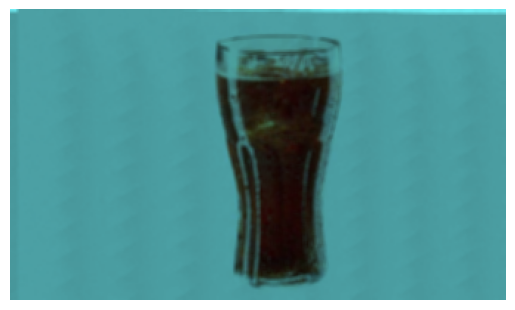

(197, 336, 3)


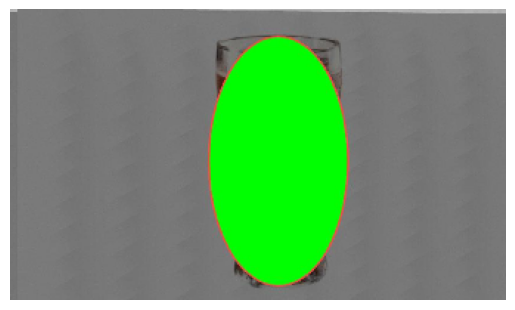

(197, 336, 3)


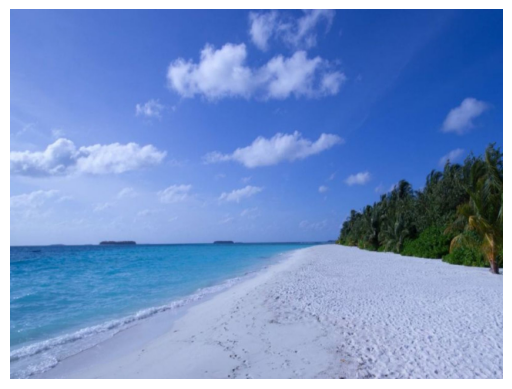

(480, 640, 3)


In [5]:

plt.imshow(img)
plt.axis('off')
plt.show()
print(img.shape)
plt.imshow(img_marked)
plt.axis('off')
plt.show()
print(img_marked.shape)
plt.imshow(back)
plt.axis('off')
plt.show()
print(back.shape)